#  **Machine Learning**

## **Importing libraries**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [21]:
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi']=150
plt.rcParams['font.size']=12

## **Loading dataset**

In [22]:
df=sns.load_dataset('titanic')

## **Have a look on the five random rows of the data**

In [23]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
773,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
457,1,1,female,NaN,1,0,51.8625,S,First,woman,False,D,Southampton,yes,False
713,0,3,male,29.0,0,0,9.4833,S,Third,man,True,NaN,Southampton,no,True
663,0,3,male,36.0,0,0,7.4958,S,Third,man,True,NaN,Southampton,no,True
59,0,3,male,11.0,5,2,46.9000,S,Third,child,False,NaN,Southampton,no,False


## **Shape of the data**

In [24]:
df.shape

(891, 15)

## **Name of the columns**

In [25]:
df.columns.to_list()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

## **Applying statics functions on the data** 

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [27]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## **Checking missing values**

In [28]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [29]:
df['deck'].isnull().sum()

688

## **Dropping deck column**

In [30]:
df.drop(columns=['deck'], inplace=True)

In [31]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [32]:
df.shape

(891, 14)

## **Filling missing values of the Age column**

In [33]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer()
df['age']=imputer.fit_transform(df[['age']]).ravel()

In [34]:
df['age'].isnull().sum()

0

## **Filling missing values in embarked column**

In [35]:
df['embarked'].isnull().sum()

2

In [36]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='most_frequent')
df['embarked']=imputer.fit_transform(df[['embarked']]).ravel()

In [37]:
df['embarked'].isnull().sum()

0

## **Heatmap to check the relation of survived column with others columns**

In [38]:
df_corr=df.select_dtypes(include=[np.number])

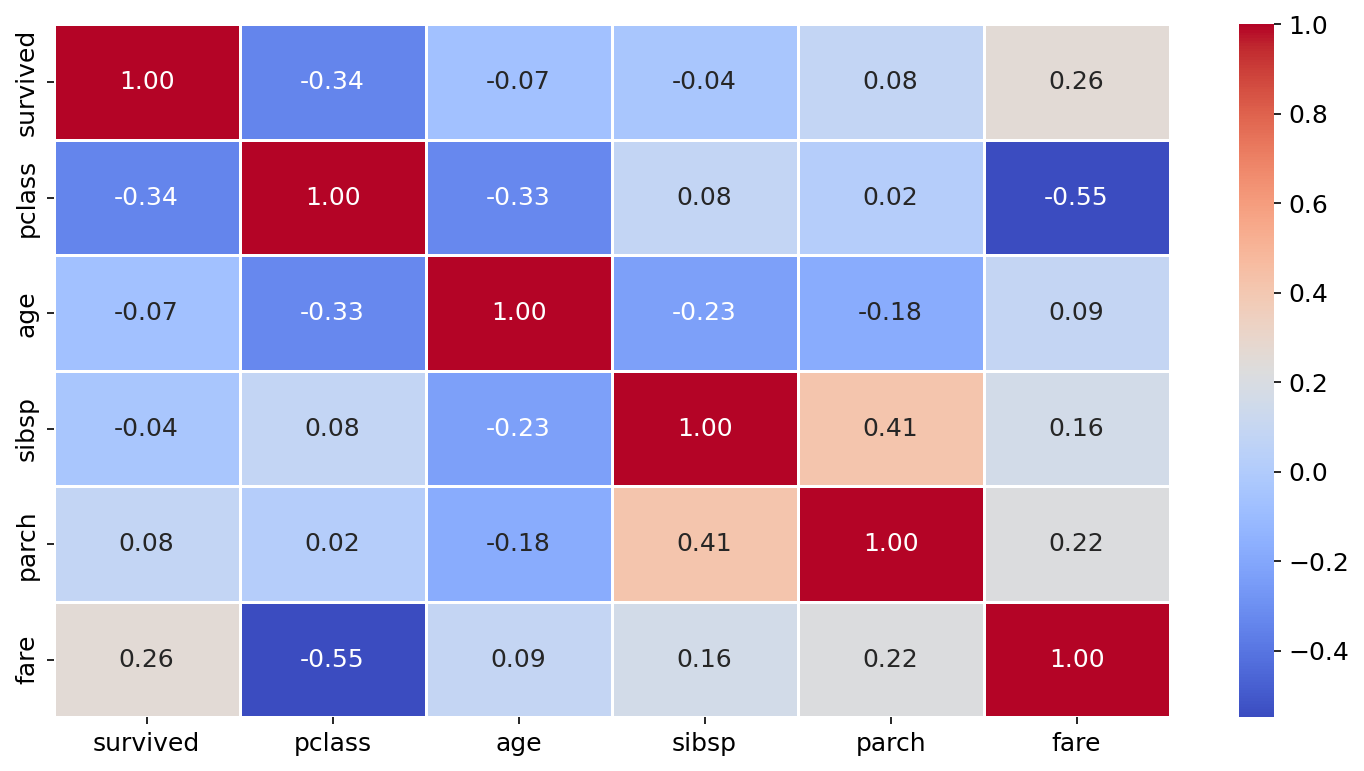

In [41]:
# Heatmap to check the relationship between the features and the target variable
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

In [42]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

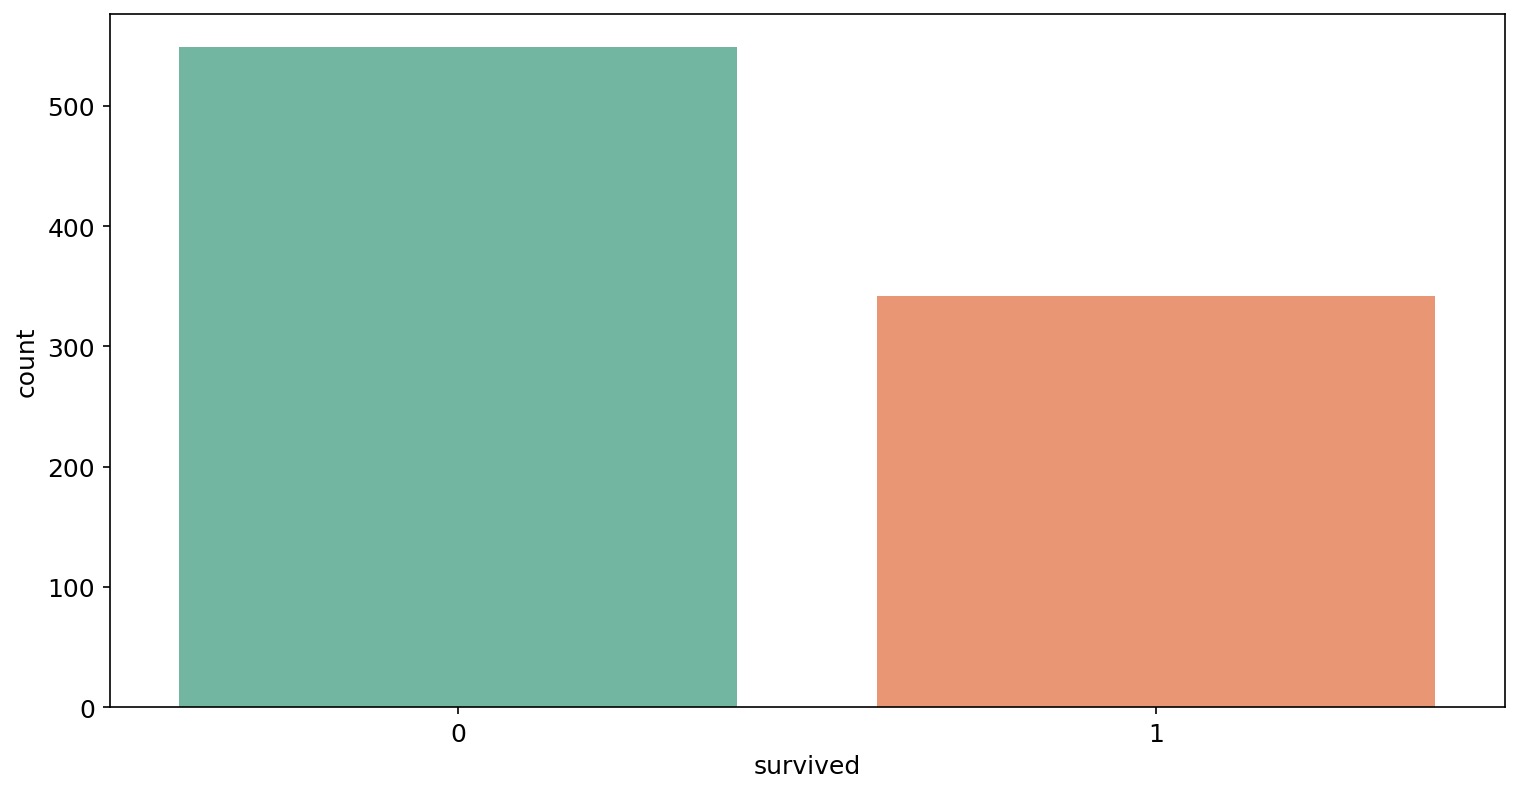

In [45]:
sns.countplot(x='survived', data=df,palette='Set2')
plt.show()

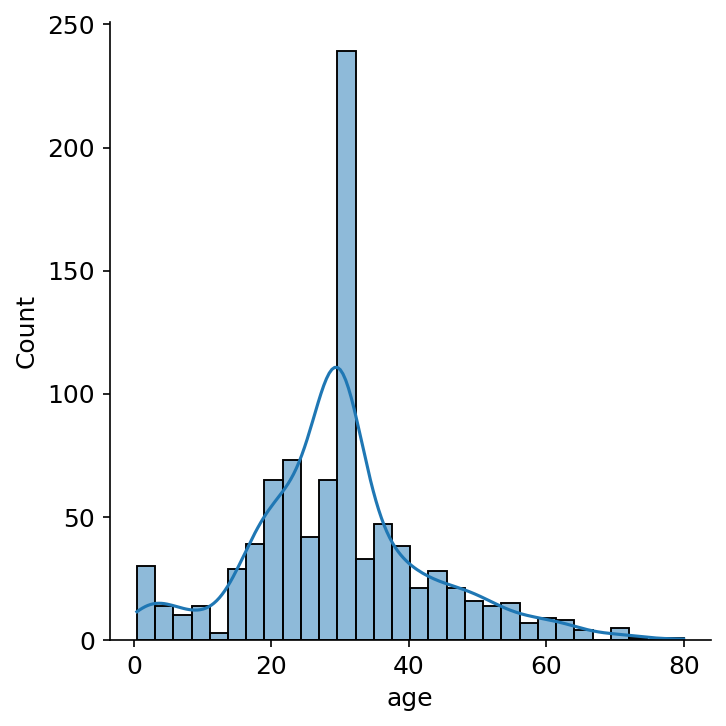

In [47]:
sns.displot(x='age',data=df,kde=True)
plt.show()

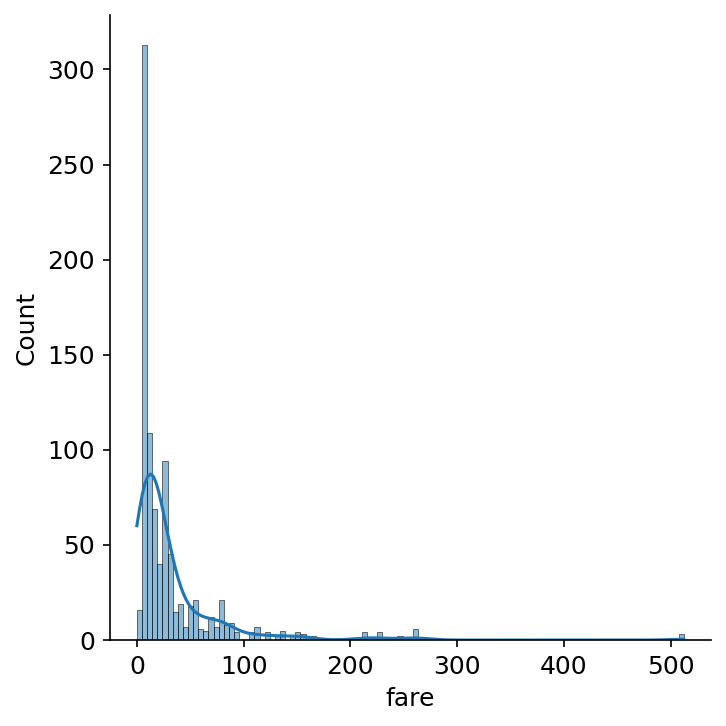

In [49]:
sns.displot(x='fare',data=df,kde=True)
plt.show()

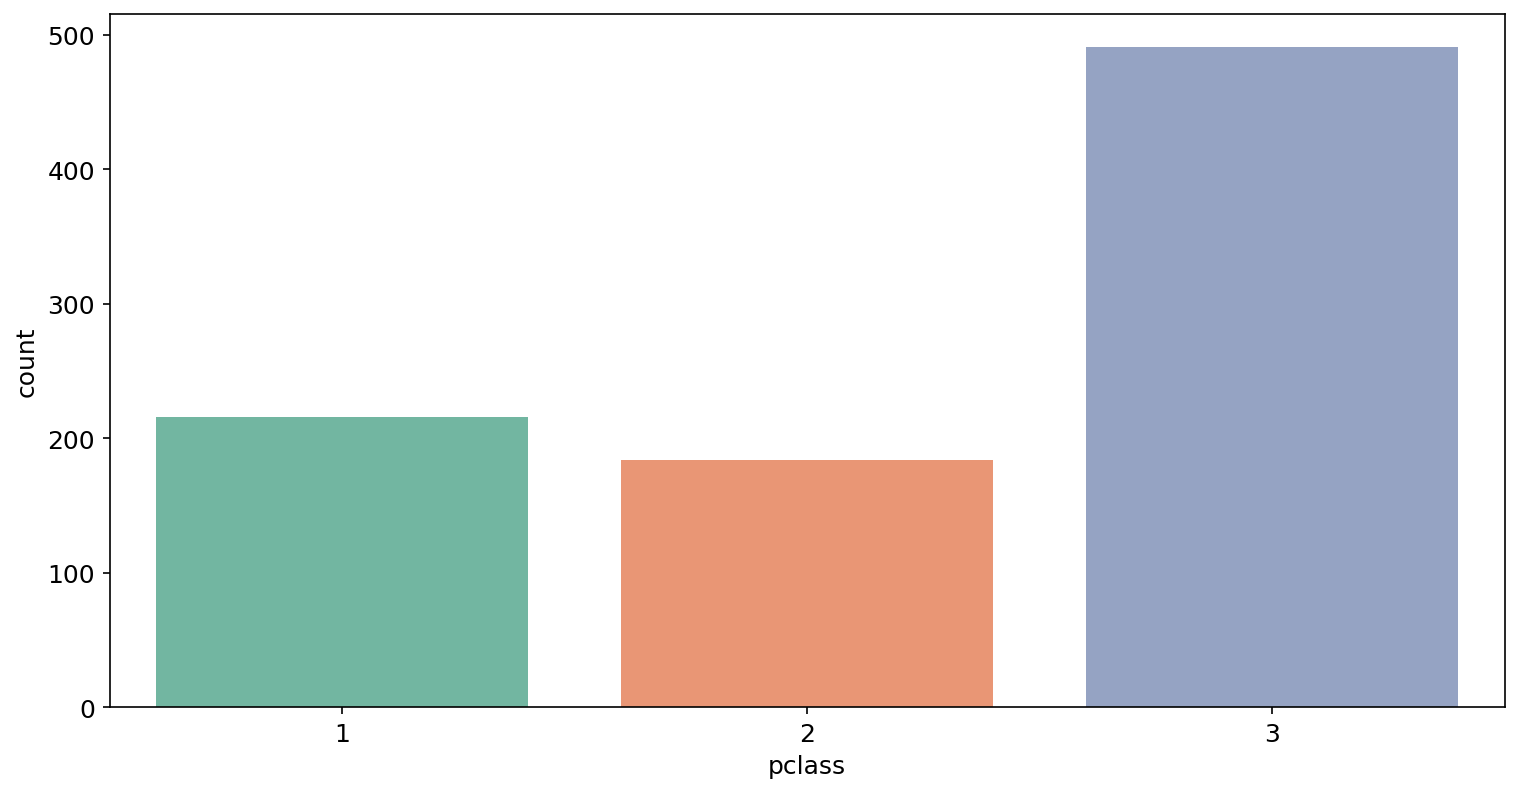

In [56]:
sns.countplot(x='pclass',data=df,palette='Set2')
plt.show()

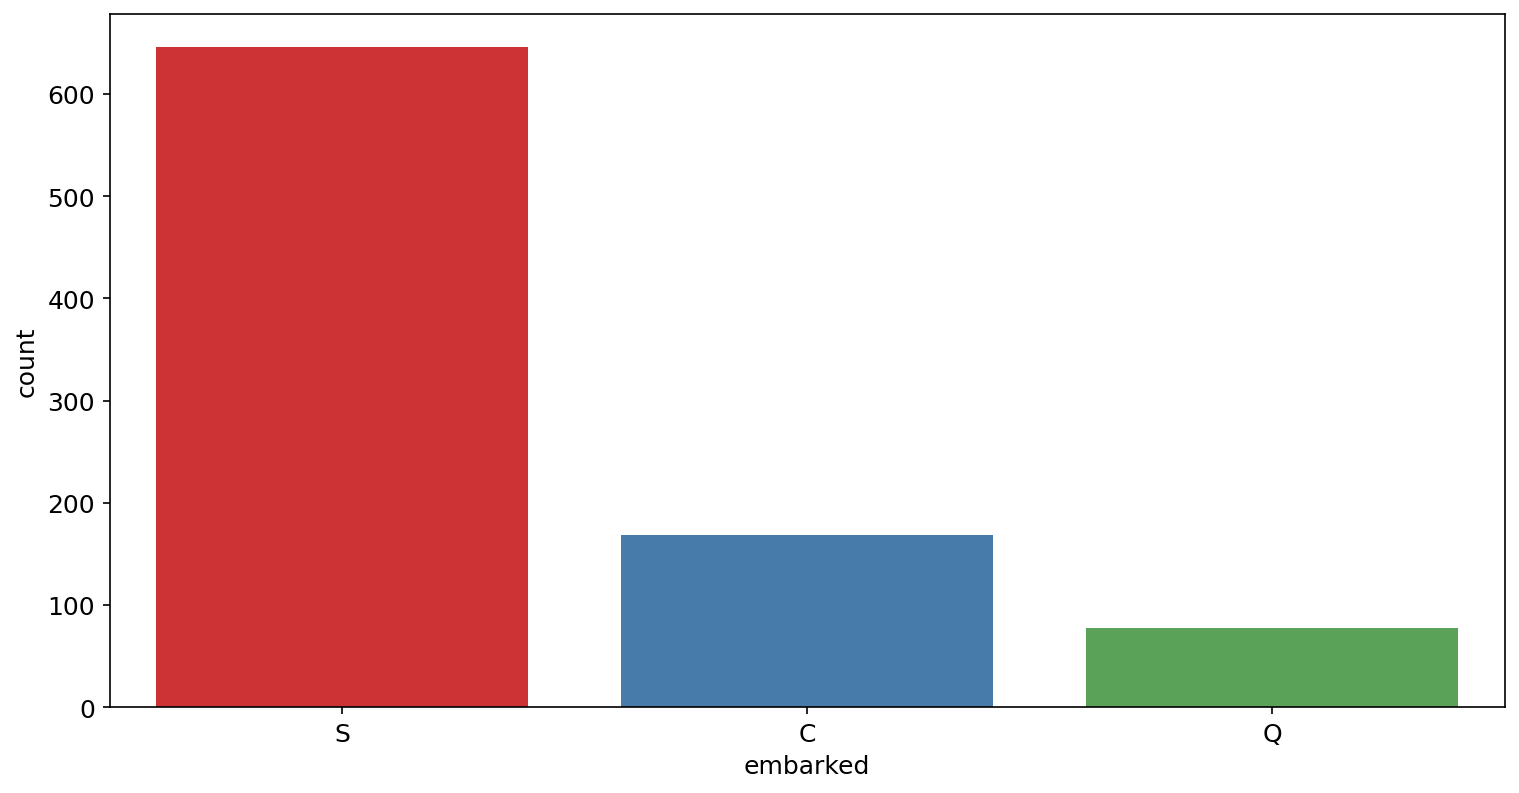

In [57]:
sns.countplot(x='embarked',data=df,palette='Set1')
plt.show()

In [53]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


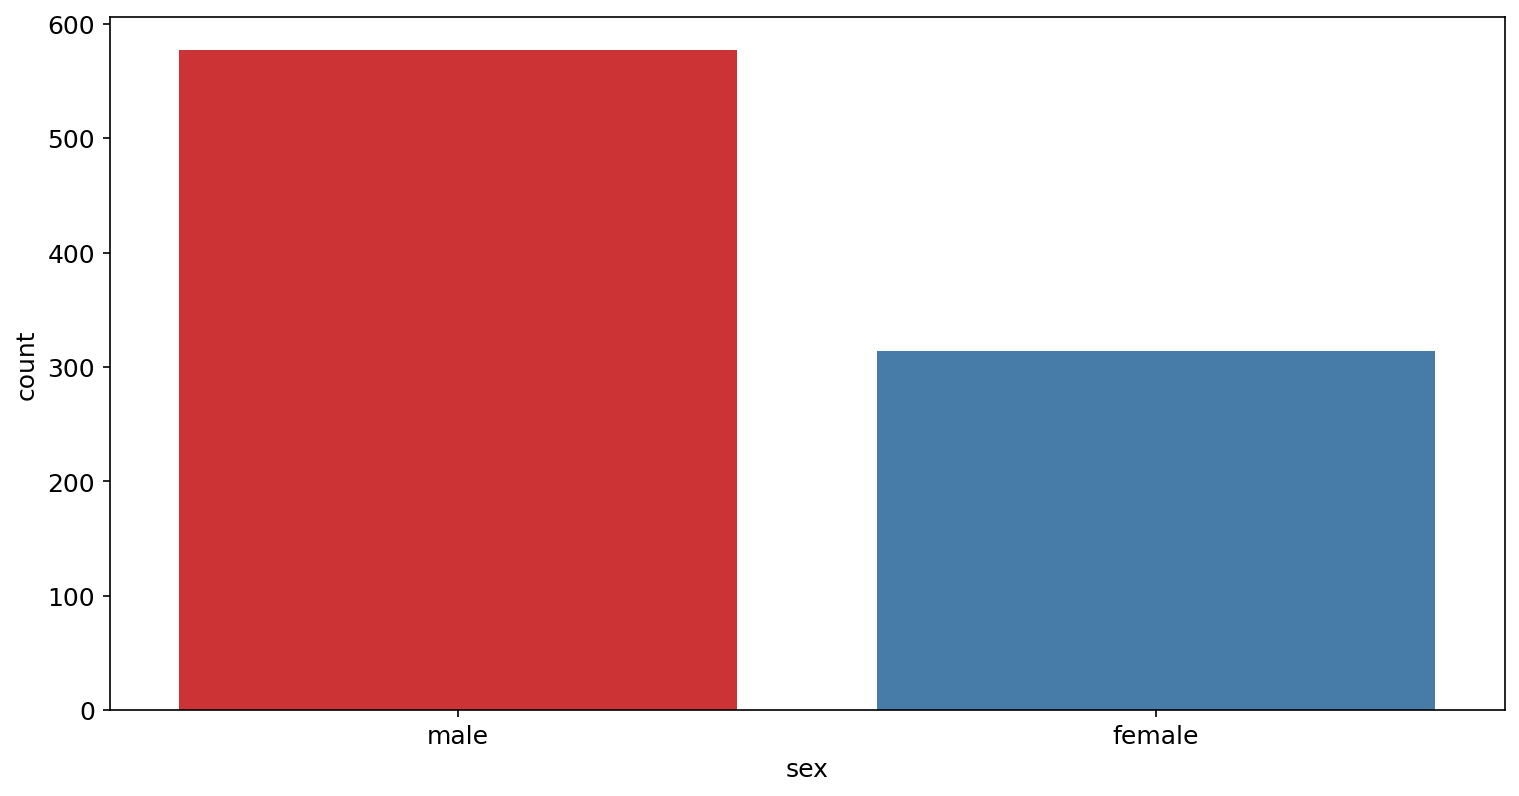

In [58]:
sns.countplot(x='sex', data=df,palette='Set1')
plt.show()

In [59]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [61]:
df['family_size']=df['sibsp']+df['parch']
df['family_size'].value_counts()

family_size
0     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64

In [62]:
df['family']=df['family_size'].apply(lambda x: 'Alone' if x==0 else ('Small' if x<=3 else 'Large'))

In [63]:
df['family'].value_counts()

family
Alone    537
Small    292
Large     62
Name: count, dtype: int64

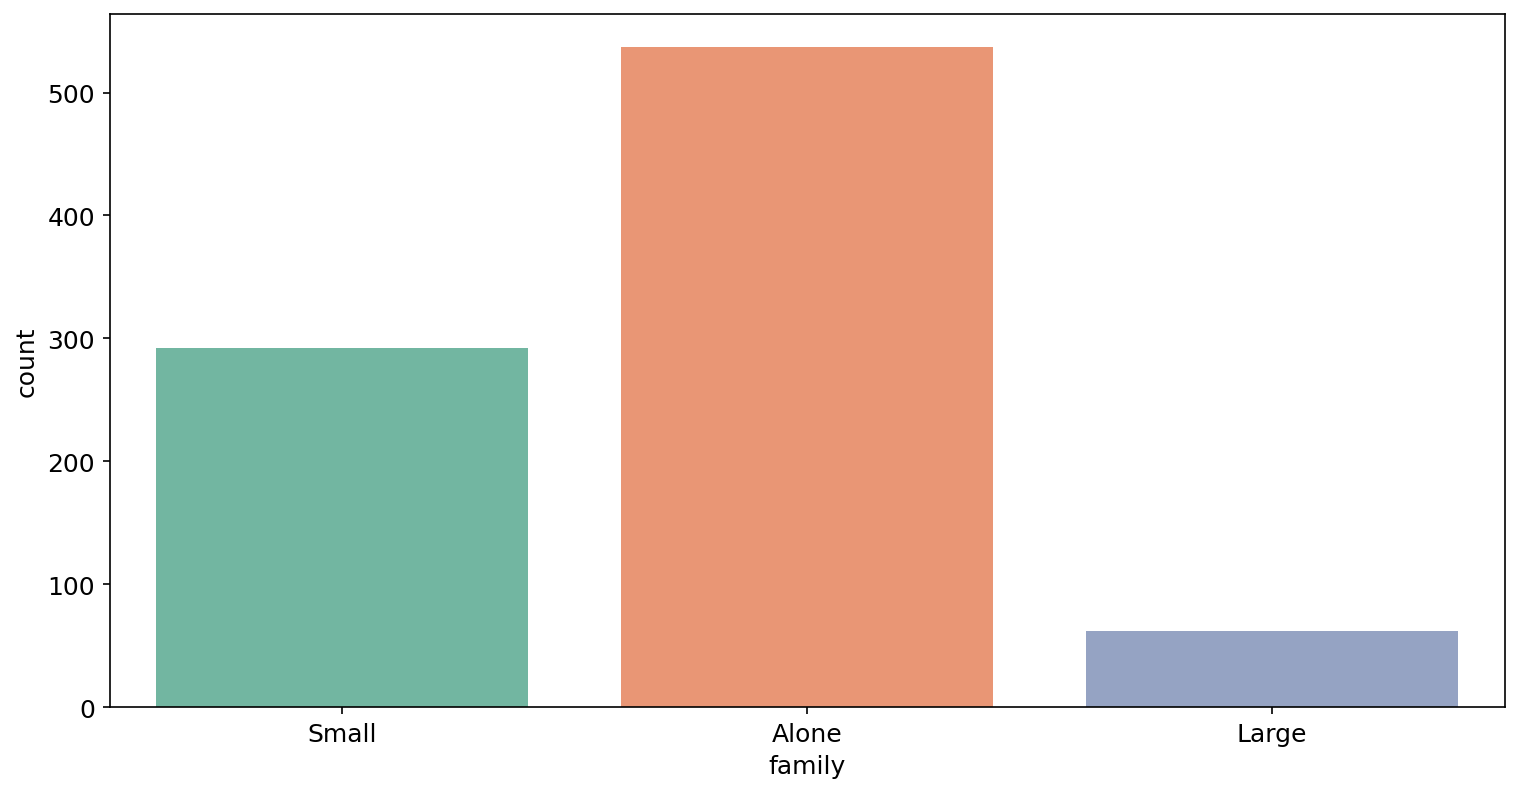

In [66]:
sns.countplot(x='family', data=df,palette='Set2')
plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
